## Cabeçalho e imports

In [110]:
#  Imports e paths
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

sns.set_style("whitegrid")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
OUT = ROOT / "outputs"
PROC = ROOT / "data" / "processed"


# arquivos
conc_file = OUT / "conciliation_results_with_rates.csv"
kpis_file = OUT / "kpis_summary.json"
facio_file = PROC / "facio_tratado.parquet"
fundo_file = PROC / "fundo_tratado.parquet"


facio_palette = ["#003366", "#00A86B", "#66C2A5", "#FC8D62"]


## Carregar dados

In [111]:
# Carregar dados e KPIs
candidate_paths = [
    conc_file,
    OUT / "conciliation_results_with_rates.csv",
    PROC / "conciliation_results_with_rates.csv",
    ROOT / "conciliation_results_with_rates.csv"

]

for path in candidate_paths:
    if path.exists():
        df = pd.read_csv(path)
        break
else:
    raise FileNotFoundError(
        f"Arquivo de reconciliação não encontrado. Verifique os caminhos esperados: {candidate_paths}"
    )
with open(kpis_file, 'r', encoding='utf-8') as fh:
    kpis = json.load(fh)

print("KPIs:", kpis)
df.head()


KPIs: {'total_rows': 49999, 'counts_by_status': {'Match Exact': 35849, 'Only Fundo': 9295, 'Match Divergent': 4846, 'Only Facio': 9}, 'vp_total_exposicao': 9233833.336625725, 'vp_total_facio': 7786711.143849044, 'vp_total_fundo': 9056501.01602084, 'total_abs_diff_divergentes': 176438.13951674267}


,customerid,transactionid,id_contrato,parcela,produto,fundo,data_referencia,data_cessao,data_vencimento,valor_cessao,...,dc_cessao,t_ref,i_facio,valor_presente_calculado,valor_presente_fundo,_merge,recon_status,abs_diff,rel_diff,valor_exposicao
0,42b7be7afa750d32835412de14c3f10d2be3918d7e9ec3...,2.026041e+13,CTR000001,1.0,SalaryAdvanceFX,FIDC3,2026-06-30,2026-04-10,2026-05-09,47.50,...,29.0,81.0,0.011879,66.900000,66.900000,both,Match Exact,2.131628e-13,3.186290e-15,66.900000
1,3f9bdbb8e347c24adcb61493812b6a88695d9cc2b15fff...,2.026062e+13,CTR000002,1.0,SimpleCredit,FIDC4,2026-06-30,2026-06-19,2026-07-20,65.95,...,31.0,11.0,0.009151,72.901045,72.901045,both,Match Exact,4.379800e-09,6.007869e-11,72.901045
2,57261241ca541d83b9edcfdffe2b186f07bf82e26345a8...,2.026053e+13,CTR000003,1.0,SalaryAdvanceFX,FIDC4,2026-06-30,2026-05-29,2026-07-07,360.50,...,39.0,32.0,0.005000,422.876666,421.820000,both,Match Divergent,1.056666e+00,2.505015e-03,422.876666
3,NaN,NaN,NaN,NaN,NaN,FACIO 4 FUNDO DE INVESTIMENTO EM DIREITOS CRED...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,152.900000,right_only,Only Fundo,NaN,NaN,152.900000
4,7e18f618ba049e808192b7afa7450b6e9afe57240686ca...,2.026060e+13,CTR000005,1.0,SimpleCredit,FIDC4,2026-06-30,2026-06-02,2026-07-16,102.23,...,44.0,28.0,0.005711,119.902046,119.902046,both,Match Exact,1.030628e-09,8.595583e-12,119.902046


In [112]:
# =====================================
# Normalização dos nomes dos fundos
# =====================================

fundo_mapping = {
    "FACIO 3 FUNDO DE INVESTIMENTO EM DIREITOS CREDITÓRIOS FINANCEIROS DE RESPONSABILIDADE LIMITADA": "FIDC3",
    "FACIO 4 FUNDO DE INVESTIMENTO EM DIREITOS CREDITÓRIOS FINANCEIROS DE RESPONSABILIDADE LIMITADA": "FIDC4"
}


df["fundo_resumido"] = (
    df["fundo"]
    .replace(fundo_mapping)
    .fillna(df["fundo"])
)


print("Fundos encontrados após normalização:")
display(df["fundo_resumido"].value_counts())

Fundos encontrados após normalização:


fundo_resumido
FIDC4    39551
FIDC3    10448
Name: count, dtype: int64

## Cálculo de taxa implícita e VP (Q1)

C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\1088101696.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=status_counts.index, y=status_counts.values, palette=facio_palette)


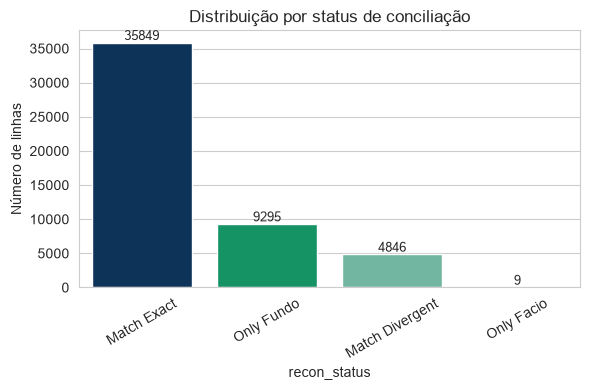

In [113]:
# Gráfico de distribuição por status
status_counts = df['recon_status'].value_counts()

plt.figure(figsize=(6,4))
ax = sns.barplot(x=status_counts.index, y=status_counts.values, palette=facio_palette)
plt.title("Distribuição por status de conciliação")
plt.ylabel("Número de linhas")
plt.xticks(rotation=30)

# adicionar rótulos com os valores em cima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)

# salvar como PNG
plt.tight_layout()
out_path = OUT / "figures" / "distribuicao_status.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches="tight")  # caminho + nome do arquivo
plt.show()


recon_status,Match Divergent,Match Exact,Only Facio,total
produto,,,,
SimpleCredit,192826.540000,5.188444e+06,1001.71,5.382272e+06
SalaryAdvanceFX,938951.329338,1.393281e+06,0.00,2.332232e+06
eConsignado,18452.234687,5.375481e+04,0.00,7.220704e+04


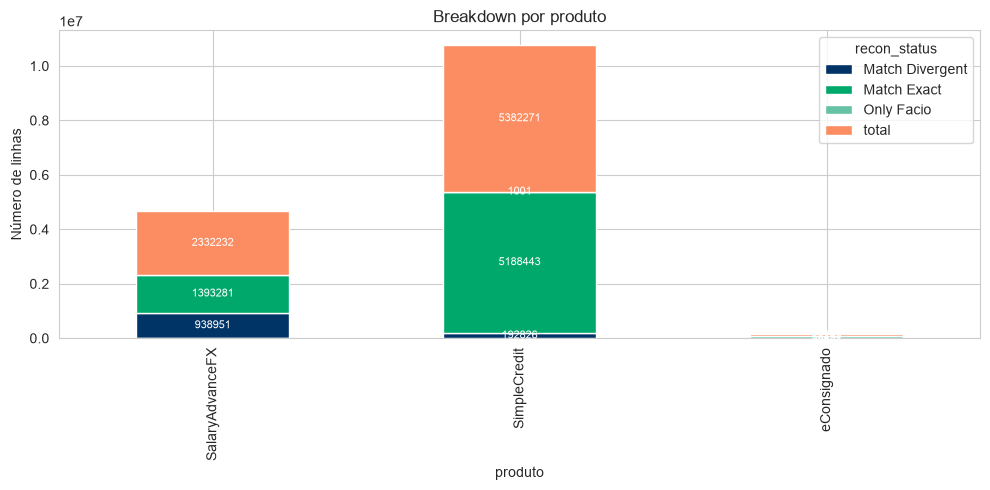

In [114]:
if 'produto' in df.columns:
    pivot_prod = (
    df.groupby(["produto","recon_status"])
      ["valor_exposicao"]
      .sum()
      .unstack(fill_value=0)
)
    pivot_prod['total'] = pivot_prod.sum(axis=1)
    display(pivot_prod.sort_values('total', ascending=False).head(10))

    # plot com paleta Facio
    ax = pivot_prod.plot(kind='bar', stacked=True, figsize=(10,5),
                         color=facio_palette[:len(pivot_prod.columns)])

    plt.title("Breakdown por produto")
    plt.ylabel("Número de linhas")

    # adicionar rótulos com os valores em cada segmento
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        if height > 0:  # só mostrar se houver valor
            x, y = p.get_xy()
            ax.text(x + width/2, y + height/2,
                    f'{int(height)}',
                    ha='center', va='center', fontsize=8, color='white')

    # salvar como PNG
    plt.tight_layout()
    out_path = OUT / "figures" / "breakdown_produto_final.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")  # caminho + nome do arquivo
    plt.show()

recon_status,Match Divergent,Match Exact,Only Facio,Only Fundo,total
fundo_resumido,,,,,
FIDC4,1.065666e+06,6.071580e+06,447.98,1.106963e+06,8.244657e+06
FIDC3,8.456376e+04,5.638993e+05,553.73,3.401591e+05,9.891759e+05


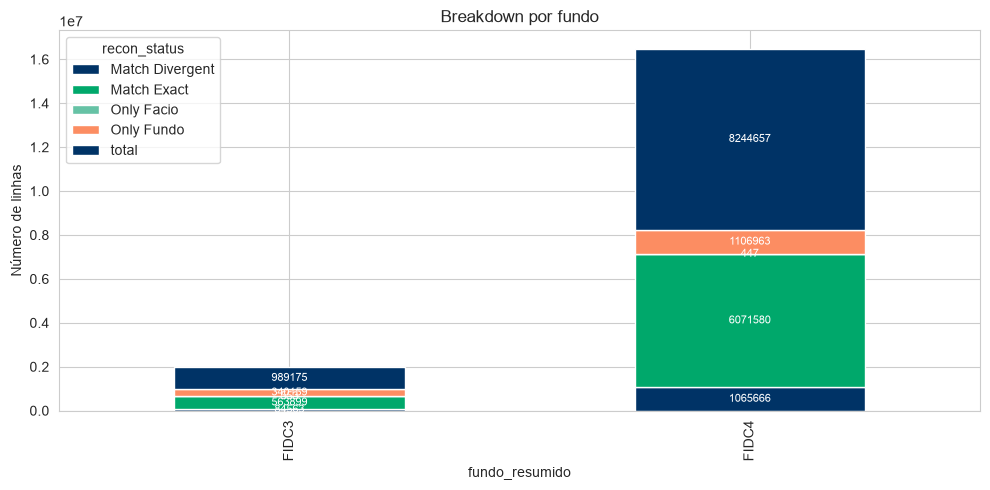

In [115]:
# Breakdown por fundo
if 'fundo_resumido' in df.columns or 'fundo' in df.columns:
    fundo_col = 'fundo_resumido' if 'fundo_resumido' in df.columns else 'fundo'
    pivot_fundo = df.groupby([fundo_col,'recon_status'])['valor_exposicao'].sum().unstack(fill_value=0)
    pivot_fundo['total'] = pivot_fundo.sum(axis=1)
    display(pivot_fundo.sort_values('total', ascending=False))

    # plot com paleta Facio
    ax = pivot_fundo.plot(kind='bar', stacked=True, figsize=(10,5),
                          color=facio_palette[:len(pivot_fundo.columns)])

    plt.title("Breakdown por fundo")
    plt.ylabel("Número de linhas")

    # adicionar rótulos com os valores em cada segmento
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        if height > 0:
            x, y = p.get_xy()
            ax.text(x + width/2, y + height/2,
                    f'{int(height)}',
                    ha='center', va='center', fontsize=8, color='white')

   

  # salvar como PNG
    plt.tight_layout()
    out_path = OUT / "figures" / "breakdown_fundo_final.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")  # caminho + nome do arquivo
    plt.show()
   

,id_contrato,produto,fundo,dc_cessao,i_facio,valor_presente_calculado,valor_presente_fundo,abs_diff,rel_diff
27862,CTR027641,SalaryAdvanceFX,FIDC4,44.0,0.005286,1298.90,386.96,911.94,2.356678
11174,CTR011093,SimpleCredit,FIDC4,24.0,0.009172,566.82,66.99,499.83,7.461263
19423,CTR019269,SimpleCredit,FIDC4,28.0,0.006914,864.65,451.70,412.95,0.914213
30557,CTR030315,SalaryAdvanceFX,FIDC4,31.0,0.006324,619.90,226.42,393.48,1.737832
11503,CTR011422,SalaryAdvanceFX,FIDC4,45.0,0.004670,563.90,200.34,363.56,1.814715
49816,CTR049396,SalaryAdvanceFX,FIDC4,40.0,0.006468,439.90,79.46,360.44,4.536119
46733,CTR046340,SalaryAdvanceFX,FIDC4,31.0,0.006273,543.90,196.48,347.42,1.768221
4796,CTR004747,SalaryAdvanceFX,FIDC4,32.0,0.006059,374.90,29.47,345.43,11.721412
20328,CTR020174,SalaryAdvanceFX,FIDC4,43.0,0.006044,573.90,243.91,329.99,1.352917
34314,CTR034040,SalaryAdvanceFX,FIDC4,44.0,0.004670,845.90,519.49,326.41,0.628328


C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\507860602.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_div['key'], y=top_div['abs_diff'], palette=facio_palette)
C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\507860602.py:21: UserWarning: 
The palette list has fewer values (4) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=top_div['key'], y=top_div['abs_diff'], palette=facio_palette)


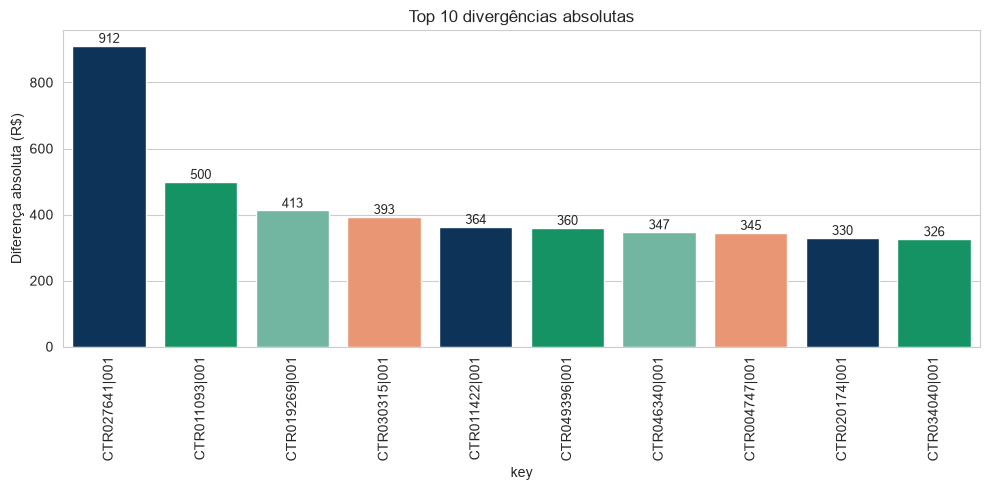

In [116]:
# Definir paleta Facio
facio_palette = ["#003366", "#00A86B", "#66C2A5", "#FC8D62"]

# Top divergências
display(
    top_div[
        [
        "id_contrato",
        "produto",
        "fundo",
        "dc_cessao",
        "i_facio",
        "valor_presente_calculado",
        "valor_presente_fundo",
        "abs_diff",
        "rel_diff"
        ]
    ]
)
plt.figure(figsize=(10,5))
ax = sns.barplot(x=top_div['key'], y=top_div['abs_diff'], palette=facio_palette)

plt.title("Top 10 divergências absolutas")
plt.ylabel("Diferença absoluta (R$)")
plt.xticks(rotation=90)

# adicionar rótulos com os valores em cima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9)



plt.tight_layout()
out_path = OUT / "figures" / "top10_divergencias.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches="tight")  # caminho + nome do arquivo
plt.show()





C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\3221954898.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\3221954898.py:78: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.barplot(


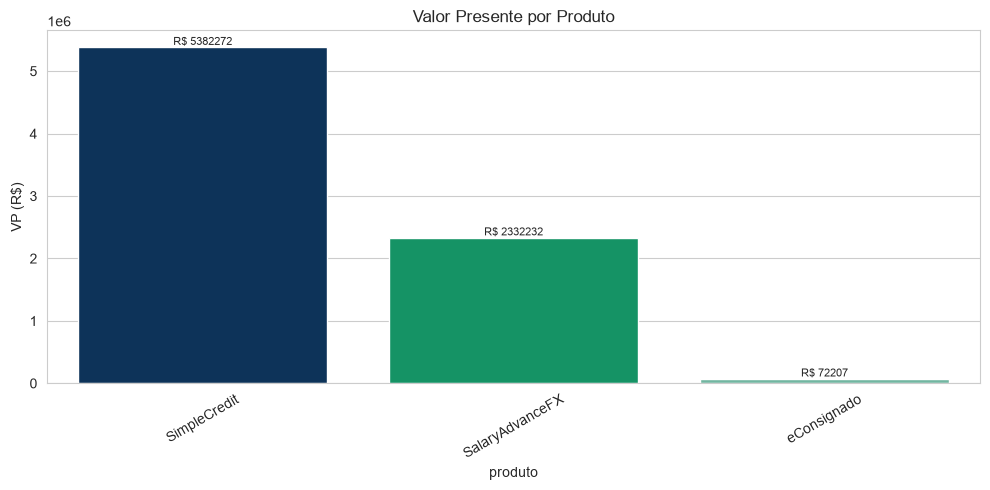

C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\3221954898.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\3221954898.py:116: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(


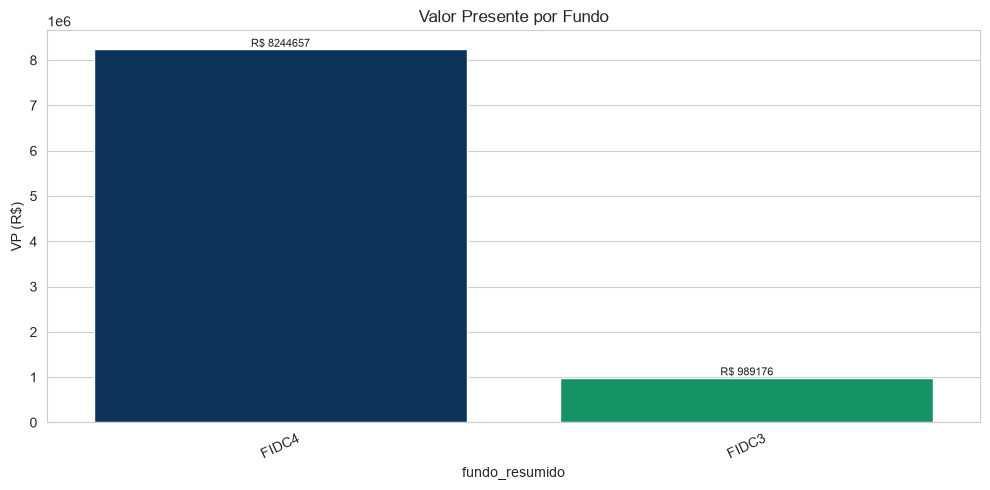

C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\3221954898.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("bucket_prazo")["vp"]
C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\3221954898.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


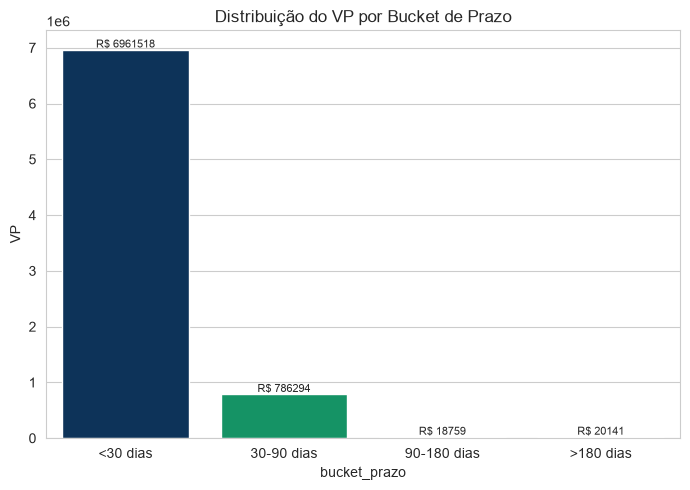

C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\3221954898.py:180: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,fundo_resumido,duration
0,FIDC3,NaN
1,FIDC4,NaN


fundo_resumido
FIDC3    56.350032
FIDC4    77.675962
Name: % até 30 dias, dtype: float64

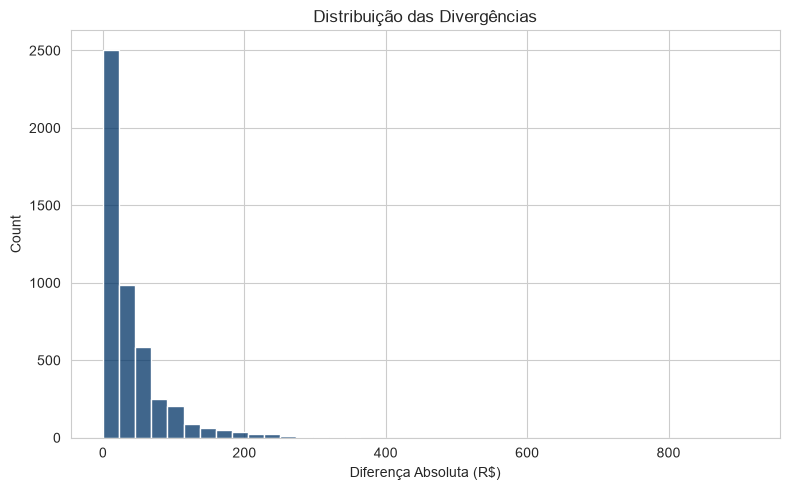

C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\3221954898.py:249: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\3221954898.py:249: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(


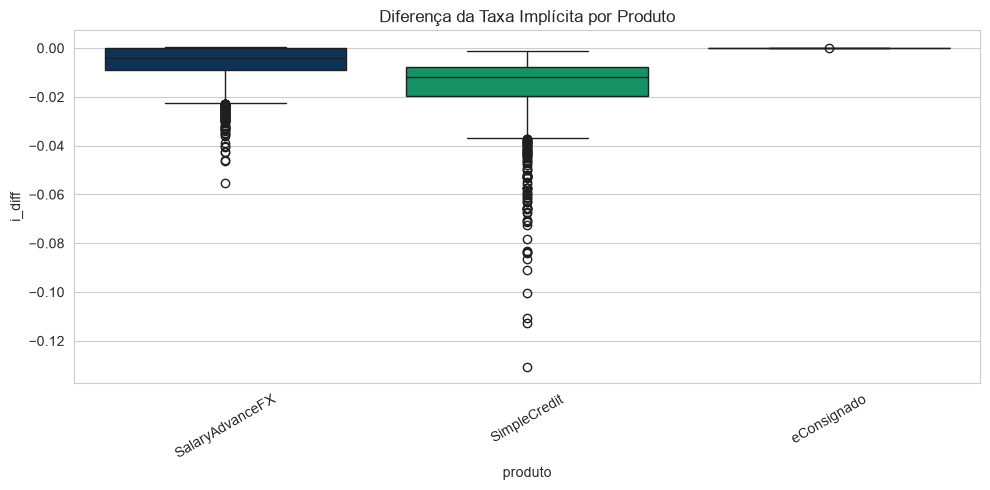

C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\3221954898.py:275: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Caah\AppData\Local\Temp\ipykernel_11924\3221954898.py:275: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(


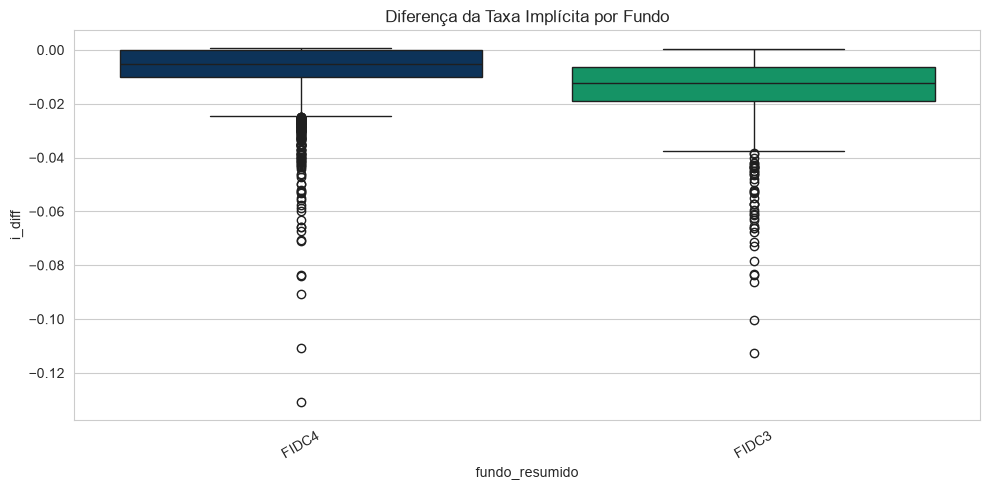

,key,produto,fundo_resumido,dias_vencer,i_facio,i_fundo,i_diff,abs_diff,rel_diff
27862,CTR027641|001,SalaryAdvanceFX,FIDC4,-80.0,0.005286,-0.007864,-0.013150,911.94,2.356678
11174,CTR011093|001,SimpleCredit,FIDC4,-8.0,0.009172,-0.058129,-0.067301,499.83,7.461263
19423,CTR019269|001,SimpleCredit,FIDC4,-25.0,0.006914,-0.008574,-0.015488,412.95,0.914213
30557,CTR030315|001,SalaryAdvanceFX,FIDC4,-18.0,0.006324,-0.016429,-0.022754,393.48,1.737832
11503,CTR011422|001,SalaryAdvanceFX,FIDC4,-54.0,0.004670,-0.008301,-0.012971,363.56,1.814715
49816,CTR049396|001,SalaryAdvanceFX,FIDC4,-61.0,0.006468,-0.014287,-0.020755,360.44,4.536119
46733,CTR046340|001,SalaryAdvanceFX,FIDC4,-22.0,0.006273,-0.015433,-0.021706,347.42,1.768221
4796,CTR004747|001,SalaryAdvanceFX,FIDC4,-48.0,0.006059,-0.028947,-0.035007,345.43,11.721412
20328,CTR020174|001,SalaryAdvanceFX,FIDC4,-6.0,0.006044,-0.012101,-0.018145,329.99,1.352917
34314,CTR034040|001,SalaryAdvanceFX,FIDC4,-52.0,0.004670,-0.002939,-0.007609,326.41,0.628328


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Preparação
# ===============================

df["data_referencia"] = pd.to_datetime(df["data_referencia"])
df["data_cessao"] = pd.to_datetime(df["data_cessao"])
df["data_vencimento"] = pd.to_datetime(df["data_vencimento"])

# prazo remanescente
df["dias_vencer"] = (
    df["data_vencimento"] - df["data_referencia"]
).dt.days

# bucket de prazo
df["bucket_prazo"] = pd.cut(
    df["dias_vencer"],
    bins=[-99999,0,30,90,180,99999],
    labels=[
        "Vencidos",
        "<30 dias",
        "30-90 dias",
        "90-180 dias",
        ">180 dias"
    ]
)

# exposição usada na análise
df["vp"] = df["valor_presente_calculado"].fillna(
    df["valor_presente_fundo"]
)

# ===============================
# Taxa implícita do Fundo
# ===============================

mask = (
    (df["recon_status"]=="Match Divergent")
    &
    (df["valor_presente_fundo"]>0)
    &
    (df["valor_cessao"]>0)
)

df["i_fundo"] = np.nan

dias = (
    df.loc[mask,"data_referencia"]
    -
    df.loc[mask,"data_cessao"]
).dt.days

dias = dias.clip(lower=1)

df.loc[mask,"i_fundo"] = (
    (
        df.loc[mask,"valor_presente_fundo"] /
        df.loc[mask,"valor_cessao"]
    ) ** (1/dias)
) - 1

df["i_diff"] = df["i_fundo"] - df["i_facio"]

# ===============================
# VP por produto
# ===============================

vp_produto = (
    df.groupby("produto")["vp"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=vp_produto.index,
    y=vp_produto.values,
    palette=facio_palette
)

plt.title("Valor Presente por Produto")
plt.ylabel("VP (R$)")
plt.xticks(rotation=30)

for c in ax.containers:
    ax.bar_label(
        c,
        fmt="R$ %.0f",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(
    OUT/"figures"/"vp_produto.png",
    dpi=300
)
plt.show()

# ===============================
# VP por Fundo
# ===============================

fundo_col = "fundo_resumido"

vp_fundo = (
    df.groupby(fundo_col)["vp"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=vp_fundo.index,
    y=vp_fundo.values,
    palette=facio_palette
)

plt.title("Valor Presente por Fundo")
plt.ylabel("VP (R$)")
plt.xticks(rotation=25)

for c in ax.containers:
    ax.bar_label(
        c,
        fmt="R$ %.0f",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(
    OUT/"figures"/"vp_fundo.png",
    dpi=300
)
plt.show()

# ===============================
# Bucket de Prazo
# ===============================

bucket = (
    df.groupby("bucket_prazo")["vp"]
      .sum()
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=bucket.index,
    y=bucket.values,
    palette=facio_palette
)

plt.title("Distribuição do VP por Bucket de Prazo")
plt.ylabel("VP")

for c in ax.containers:
    ax.bar_label(
        c,
        fmt="R$ %.0f",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(
    OUT/"figures"/"bucket_prazo.png",
    dpi=300
)
plt.show()

# ===============================
# Duration Média Ponderada por VP
# Considerando somente parcelas futuras
# ===============================

duration_base = df[
    (df["data_vencimento"].notna()) &
    (df["vp"].notna()) &
    (df["dias_vencer"] >= 0)
].copy()


duration = (
    duration_base
    .groupby("fundo_resumido")
    .apply(
        lambda x: np.average(
            x["dias_vencer"],
            weights=x["vp"]
        ),
        include_groups=False
    )
    .rename("duration_dias")
    .reset_index()
)


display(duration)

# ===============================
# % vencendo em 30 dias
# ===============================

v30 = (
    df[df["dias_vencer"]<=30]
    .groupby(fundo_col)["vp"]
    .sum()
)

total = (
    df.groupby(fundo_col)["vp"]
    .sum()
)

conc = (
    (v30/total*100)
    .fillna(0)
    .rename("% até 30 dias")
)

display(conc)

# ===============================
# Distribuição da Divergência
# ===============================

div = df[
    df["recon_status"]=="Match Divergent"
]

plt.figure(figsize=(8,5))

ax = sns.histplot(
    div["abs_diff"],
    bins=40,
    color=facio_palette[0]
)

plt.title("Distribuição das Divergências")
plt.xlabel("Diferença Absoluta (R$)")
plt.tight_layout()

plt.savefig(
    OUT/"figures"/"hist_divergencias.png",
    dpi=300
)

plt.show()

# ===============================
# Boxplot da diferença de taxa
# ===============================

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df[df["i_diff"].notna()],
    x="produto",
    y="i_diff",
    palette=facio_palette
)

plt.xticks(rotation=30)

plt.title("Diferença da Taxa Implícita por Produto")

plt.tight_layout()

plt.savefig(
    OUT/"figures"/"boxplot_taxa_produto.png",
    dpi=300
)

plt.show()

# ===============================
# Boxplot por Fundo
# ===============================

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df[df["i_diff"].notna()],
    x=fundo_col,
    y="i_diff",
    palette=facio_palette
)

plt.xticks(rotation=30)

plt.title("Diferença da Taxa Implícita por Fundo")

plt.tight_layout()

plt.savefig(
    OUT/"figures"/"boxplot_taxa_fundo.png",
    dpi=300
)

plt.show()

# ===============================
# Top divergências enriquecidas
# ===============================

top10 = (
    df[df["recon_status"]=="Match Divergent"]
    .sort_values("abs_diff",ascending=False)
    .head(10)[[
        "key",
        "produto",
        fundo_col,
        "dias_vencer",
        "i_facio",
        "i_fundo",
        "i_diff",
        "abs_diff",
        "rel_diff"
    ]]
)

display(top10)

## Exposição Financeira

In [118]:
print("="*80)
print("QUESTÃO 2 - ANÁLISE DE EXPOSIÇÃO FINANCEIRA")
print("="*80)

df["valor_exposicao"] = (
    df["valor_presente_calculado"]
    .fillna(df["valor_presente_fundo"])
)

# Exposição por status
exposicao_status = (
    df.groupby("recon_status")
      .agg(
          quantidade=("key","count"),
          exposicao=("valor_exposicao","sum")
      )
      .sort_values("exposicao", ascending=False)
)

display(exposicao_status)

# Exposição por produto
exposicao_produto = (
    df.groupby("produto")
      .agg(
          quantidade=("key","count"),
          exposicao=("valor_exposicao","sum")
      )
      .sort_values("exposicao", ascending=False)
)

display(exposicao_produto)

print("\nResumo das divergências")

display(
    div["abs_diff"].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])
)

print("\nTop 10 divergências")

display(top10)

QUESTÃO 2 - ANÁLISE DE EXPOSIÇÃO FINANCEIRA


,quantidade,exposicao
recon_status,,
Match Exact,35849,6.635479e+06
Only Fundo,9295,1.447122e+06
Match Divergent,4846,1.150230e+06
Only Facio,9,1.001710e+03


,quantidade,exposicao
produto,,
SimpleCredit,30042,5.382272e+06
SalaryAdvanceFX,10205,2.332232e+06
eConsignado,457,7.220704e+04



Resumo das divergências


count    4846.000000
mean       36.409026
std        49.842005
min         0.010679
25%         1.152578
50%        21.290000
75%        50.000000
90%        94.845000
95%       131.475000
99%       232.582500
max       911.940000
Name: abs_diff, dtype: float64


Top 10 divergências


,key,produto,fundo_resumido,dias_vencer,i_facio,i_fundo,i_diff,abs_diff,rel_diff
27862,CTR027641|001,SalaryAdvanceFX,FIDC4,-80.0,0.005286,-0.007864,-0.013150,911.94,2.356678
11174,CTR011093|001,SimpleCredit,FIDC4,-8.0,0.009172,-0.058129,-0.067301,499.83,7.461263
19423,CTR019269|001,SimpleCredit,FIDC4,-25.0,0.006914,-0.008574,-0.015488,412.95,0.914213
30557,CTR030315|001,SalaryAdvanceFX,FIDC4,-18.0,0.006324,-0.016429,-0.022754,393.48,1.737832
11503,CTR011422|001,SalaryAdvanceFX,FIDC4,-54.0,0.004670,-0.008301,-0.012971,363.56,1.814715
49816,CTR049396|001,SalaryAdvanceFX,FIDC4,-61.0,0.006468,-0.014287,-0.020755,360.44,4.536119
46733,CTR046340|001,SalaryAdvanceFX,FIDC4,-22.0,0.006273,-0.015433,-0.021706,347.42,1.768221
4796,CTR004747|001,SalaryAdvanceFX,FIDC4,-48.0,0.006059,-0.028947,-0.035007,345.43,11.721412
20328,CTR020174|001,SalaryAdvanceFX,FIDC4,-6.0,0.006044,-0.012101,-0.018145,329.99,1.352917
34314,CTR034040|001,SalaryAdvanceFX,FIDC4,-52.0,0.004670,-0.002939,-0.007609,326.41,0.628328


## Taxa Implícita

In [119]:
print("="*80)
print("QUESTÃO 3 - TAXA IMPLÍCITA DO FUNDO")
print("="*80)


taxa_stats = (
    df[df["i_diff"].notna()]
    [["i_facio","i_fundo","i_diff"]]
    .describe()
)

display(taxa_stats)


print("\nDiferença média de taxa")

print(
    df[df["i_diff"].notna()]
    ["i_diff"]
    .mean()
)


print("\nDiferença por Produto")

display(
    df[df["i_diff"].notna()]
    .groupby("produto")["i_diff"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        desvio_padrao="std"
    )
    .sort_values("media")
)


print("\nDiferença por Fundo")

display(
    df[df["i_diff"].notna()]
    .groupby("fundo_resumido")["i_diff"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        desvio_padrao="std"
    )
    .sort_values("media")
)

QUESTÃO 3 - TAXA IMPLÍCITA DO FUNDO


,i_facio,i_fundo,i_diff
count,4846.000000,4846.000000,4846.000000
mean,0.007549,-0.000540,-0.008088
std,0.003017,0.009308,0.010294
min,0.000270,-0.121677,-0.130856
25%,0.005772,-0.002226,-0.011516
50%,0.007024,0.001051,-0.006192
75%,0.008722,0.005492,-0.000144
max,0.026694,0.015202,0.000665



Diferença média de taxa
-0.008088217403419735

Diferença por Produto


,quantidade,media,mediana,desvio_padrao
produto,,,,
SimpleCredit,1147,-0.016404,-0.012029,0.014374
SalaryAdvanceFX,3567,-0.005714,-0.004242,0.006875
eConsignado,132,0.000015,0.000015,0.000007



Diferença por Fundo


,quantidade,media,mediana,desvio_padrao
fundo_resumido,,,,
FIDC3,784,-0.014541,-0.012095,0.014089
FIDC4,4062,-0.006843,-0.005192,0.008863


## Portfólio

In [128]:
print("="*80)
print("QUESTÃO 4 - COMPOSIÇÃO DO PORTFÓLIO")
print("="*80)


print("\nVP por Fundo")

display(
    df.groupby("fundo_resumido")["vp"]
      .sum()
      .sort_values(ascending=False)
      .to_frame("VP")
)


print("\nVP por Produto")

display(
    df.groupby("produto")["vp"]
      .sum()
      .sort_values(ascending=False)
      .to_frame("VP")
)


print("\nBucket de Prazo")

display(
    bucket.to_frame("VP")
)


print("\nDuration Média") 

display(duration)


print("\nPercentual vencendo em até 30 dias")

display(
    conc.to_frame()
)

QUESTÃO 4 - COMPOSIÇÃO DO PORTFÓLIO

VP por Fundo


,VP
fundo_resumido,
FIDC4,8.244657e+06
FIDC3,9.891759e+05



VP por Produto


,VP
produto,
SimpleCredit,5.382272e+06
SalaryAdvanceFX,2.332232e+06
eConsignado,7.220704e+04



Bucket de Prazo


,VP
bucket_prazo,
<30 dias,6.961518e+06
30-90 dias,7.862936e+05
90-180 dias,1.875889e+04
>180 dias,2.014076e+04



Duration Média


,fundo_resumido,duration_dias
0,FIDC3,34.741912
1,FIDC4,14.541522



Percentual vencendo em até 30 dias


,% até 30 dias
fundo_resumido,
FIDC3,56.350032
FIDC4,77.675962


## Hipóteses

In [121]:
# =====================================================
# Recalcular status de reconciliação pelo _merge real
# =====================================================

df["_merge"] = (
    df["_merge"]
    .astype(str)
    .str.strip()
)


df.loc[
    df["_merge"].eq("right_only"),
    "recon_status"
] = "Only Fundo"


df.loc[
    df["_merge"].eq("left_only"),
    "recon_status"
] = "Only Facio"


print("Status recalculado:")
display(
    df["recon_status"].value_counts(dropna=False)
)

Status recalculado:


recon_status
Match Exact        35849
Only Fundo          9295
Match Divergent     4846
Only Facio             9
Name: count, dtype: int64

In [122]:
print(df.shape)

print("\nValores do _merge:")
display(df["_merge"].value_counts(dropna=False))


print("\nExemplo de right_only:")
display(
    df[df["_merge"]=="right_only"]
    .head()
)

(49999, 30)

Valores do _merge:


_merge
both          40695
right_only     9295
left_only         9
Name: count, dtype: int64


Exemplo de right_only:


,customerid,transactionid,id_contrato,parcela,produto,fundo,data_referencia,data_cessao,data_vencimento,valor_cessao,...,recon_status,abs_diff,rel_diff,valor_exposicao,fundo_resumido,dias_vencer,bucket_prazo,vp,i_fundo,i_diff
3,NaN,NaN,NaN,NaN,NaN,FACIO 4 FUNDO DE INVESTIMENTO EM DIREITOS CRED...,NaT,NaT,NaT,NaN,...,Only Fundo,NaN,NaN,152.90,FIDC4,NaN,NaN,152.90,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,FACIO 3 FUNDO DE INVESTIMENTO EM DIREITOS CRED...,NaT,NaT,NaT,NaN,...,Only Fundo,NaN,NaN,66.90,FIDC3,NaN,NaN,66.90,NaN,NaN
22,NaN,NaN,NaN,NaN,NaN,FACIO 4 FUNDO DE INVESTIMENTO EM DIREITOS CRED...,NaT,NaT,NaT,NaN,...,Only Fundo,NaN,NaN,559.90,FIDC4,NaN,NaN,559.90,NaN,NaN
40,NaN,NaN,NaN,NaN,NaN,FACIO 3 FUNDO DE INVESTIMENTO EM DIREITOS CRED...,NaT,NaT,NaT,NaN,...,Only Fundo,NaN,NaN,55.66,FIDC3,NaN,NaN,55.66,NaN,NaN
43,NaN,NaN,NaN,NaN,NaN,FACIO 4 FUNDO DE INVESTIMENTO EM DIREITOS CRED...,NaT,NaT,NaT,NaN,...,Only Fundo,NaN,NaN,66.90,FIDC4,NaN,NaN,66.90,NaN,NaN


In [123]:
print("="*80)
print("QUESTÃO 5 - HIPÓTESES DE CAUSA RAIZ")
print("="*80)


status = (
    df["recon_status"]
    .value_counts()
)

display(status)


print("\nOnly Facio")

display(
    df[df["_merge"]=="left_only"]
.assign(
    produto=lambda x: x["produto"].fillna("Não informado")
)
[
    [
        "produto",
        "fundo_resumido"
    ]
]
.value_counts(dropna=False)
)


print("\nOnly Fundo")

only_fundo_summary = (
    df[df["_merge"]=="right_only"]
    .assign(
        produto=lambda x: x["produto"].fillna("Não informado")
    )
    [
        [
            "produto",
            "fundo_resumido"
        ]
    ]
    .value_counts(dropna=False)
)


display(only_fundo_summary)


print("\nMatch Divergent")


display(
    df[df.recon_status=="Match Divergent"]
    .groupby(
        [
            "produto",
            "fundo_resumido"
        ]
    )
    .agg(
        quantidade=("key","count"),
        media_divergencia=("abs_diff","mean"),
        media_taxa=("i_diff","mean")
    )
    .sort_values(
        "media_divergencia",
        ascending=False
    )
)

QUESTÃO 5 - HIPÓTESES DE CAUSA RAIZ


recon_status
Match Exact        35849
Only Fundo          9295
Match Divergent     4846
Only Facio             9
Name: count, dtype: int64


Only Facio


produto       fundo_resumido
SimpleCredit  FIDC3             8
              FIDC4             1
Name: count, dtype: int64


Only Fundo


produto        fundo_resumido
Não informado  FIDC4             5264
               FIDC3             4031
Name: count, dtype: int64


Match Divergent


quantidade  media_divergencia  media_taxa
produto         fundo_resumido                                           
SimpleCredit    FIDC4                  753          58.008818   -0.014716
                FIDC3                  394          37.917868   -0.019629
SalaryAdvanceFX FIDC3                  258          37.766221   -0.014219
                FIDC4                 3309          32.656931   -0.005051
eConsignado     FIDC3                  132           0.093857    0.000015